# Best Models

This notebook compares all saved model metadata files, selects the best model from each model family, and saves the best `.pkl` files into `models/best_models/`.

In [13]:
import os
import json
import shutil

import pandas as pd
import matplotlib.pyplot as plt


import joblib


from sklearn.metrics import precision_recall_curve, auc

from CartClassifier import CARTClassifier
from RandomForestFromScratch import RandomForestFromScratch

## Load saved model metadata

In [14]:
MODELS_DIR = "../models"
BEST_DIR = "../models/best_models"

os.makedirs(BEST_DIR, exist_ok=True)

rows = []

for file in os.listdir(MODELS_DIR):
    if file.endswith("_metadata.json"):
        path = os.path.join(MODELS_DIR, file)

        with open(path, "r") as f:
            meta = json.load(f)

        row = {
            "model_name": meta.get("model_name"),
            "model_type": meta.get("model_type"),
            "model_path": meta.get("model_path"),
            "val_auc": meta.get("val_auc"),
            "val_pr_auc": meta.get("val_pr_auc"),
            "val_mcc": meta.get("val_mcc"),
            "val_f1": meta.get("val_f1"),
            "val_accuracy": meta.get("val_accuracy"),
        }

        # handle nested metrics
        vm = meta.get("val_metrics", {})
        if isinstance(vm, dict):
            row["val_auc"] = row["val_auc"] or vm.get("roc_auc")
            row["val_pr_auc"] = row["val_pr_auc"] or vm.get("auprc")
            row["val_mcc"] = row["val_mcc"] or vm.get("mcc")
            row["val_f1"] = row["val_f1"] or vm.get("f1")
            row["val_accuracy"] = row["val_accuracy"] or vm.get("accuracy")

        rows.append(row)

models_df = pd.DataFrame(rows)

print("Loaded:", len(models_df))
display(models_df.head())


Loaded: 78


,model_name,model_type,model_path,val_auc,val_pr_auc,val_mcc,val_f1,val_accuracy
0,random_forest_scratch_v5,RandomForestFromScratch,../models/random_forest_scratch_v5.pkl,0.869004,0.845366,NaN,0.770241,0.782158
1,lightgbm_v7,LGBMClassifier,../models/lightgbm_v7.pkl,0.872982,NaN,0.582569,NaN,NaN
2,lightgbm_v28,LGBMClassifier,../models/lightgbm_v28.pkl,0.875562,NaN,0.603249,NaN,NaN
3,decision_tree_scratch_v2,CARTClassifier,../models/decision_tree_scratch_v2.pkl,0.817474,0.752379,NaN,0.755431,0.758645
4,xgboost_v12,XGBClassifier,../models/xgboost_v12.pkl,0.874740,NaN,NaN,NaN,NaN


In [15]:
for col in ["val_auc","val_pr_auc","val_mcc","val_f1","val_accuracy"]:
    models_df[col] = pd.to_numeric(models_df[col], errors="coerce")

display(models_df)

,model_name,model_type,model_path,val_auc,val_pr_auc,val_mcc,val_f1,val_accuracy
0,random_forest_scratch_v5,RandomForestFromScratch,../models/random_forest_scratch_v5.pkl,0.869004,0.845366,NaN,0.770241,0.782158
1,lightgbm_v7,LGBMClassifier,../models/lightgbm_v7.pkl,0.872982,NaN,0.582569,NaN,NaN
2,lightgbm_v28,LGBMClassifier,../models/lightgbm_v28.pkl,0.875562,NaN,0.603249,NaN,NaN
3,decision_tree_scratch_v2,CARTClassifier,../models/decision_tree_scratch_v2.pkl,0.817474,0.752379,NaN,0.755431,0.758645
4,xgboost_v12,XGBClassifier,../models/xgboost_v12.pkl,0.874740,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
73,lightgbm_v14,LGBMClassifier,../models/lightgbm_v14.pkl,0.858874,NaN,0.549101,NaN,NaN
74,lightgbm_v27,LGBMClassifier,../models/lightgbm_v27.pkl,0.871458,NaN,0.583036,NaN,NaN
75,adaboost_v4,AdaBoostClassifier,../models/adaboost_v4.pkl,NaN,NaN,0.524650,0.753912,0.760719
76,decision_tree_scratch_v3,CARTClassifier,../models/decision_tree_scratch_v3.pkl,0.817649,0.749941,NaN,0.754286,0.762102


In [16]:
def get_family(name):
    if name.startswith("adaboost"):
        return "AdaBoost"
    if name.startswith("xgboost"):
        return "XGBoost"
    if name.startswith("lightgbm"):
        return "LightGBM"
    if name.startswith("random_forest"):
        return "Random Forest"
    if name.startswith("decision_tree"):
        return "Decision Tree"
    return "Other"

models_df["model_family"] = models_df["model_name"].apply(get_family)

display(models_df[["model_family","model_name","val_auc","val_mcc","val_f1","val_accuracy"]])

,model_family,model_name,val_auc,val_mcc,val_f1,val_accuracy
0,Random Forest,random_forest_scratch_v5,0.869004,NaN,0.770241,0.782158
1,LightGBM,lightgbm_v7,0.872982,0.582569,NaN,NaN
2,LightGBM,lightgbm_v28,0.875562,0.603249,NaN,NaN
3,Decision Tree,decision_tree_scratch_v2,0.817474,NaN,0.755431,0.758645
4,XGBoost,xgboost_v12,0.874740,NaN,NaN,NaN
...,...,...,...,...,...,...
73,LightGBM,lightgbm_v14,0.858874,0.549101,NaN,NaN
74,LightGBM,lightgbm_v27,0.871458,0.583036,NaN,NaN
75,AdaBoost,adaboost_v4,NaN,0.524650,0.753912,0.760719
76,Decision Tree,decision_tree_scratch_v3,0.817649,NaN,0.754286,0.762102


In [17]:


models_df["rank_score"] = (
    models_df["val_auc"]
    .fillna(models_df["val_mcc"])
    .fillna(models_df["val_f1"])
    .fillna(models_df["val_accuracy"])
)

models_df = models_df.sort_values("rank_score", ascending=False)

display(models_df[[
    "model_family",
    "model_name",
    "val_auc",
    "val_mcc",
    "val_f1",
    "val_accuracy",
    "rank_score"
]])

,model_family,model_name,val_auc,val_mcc,val_f1,val_accuracy,rank_score
68,LightGBM,lightgbm_v16,0.883855,0.603249,NaN,NaN,0.883855
20,XGBoost,xgboost_v4,0.883224,NaN,NaN,NaN,0.883224
53,LightGBM,lightgbm_v24,0.882804,0.592615,NaN,NaN,0.882804
49,LightGBM,lightgbm_v6,0.882506,0.607958,NaN,NaN,0.882506
11,LightGBM,lightgbm_v31,0.882314,0.592184,NaN,NaN,0.882314
...,...,...,...,...,...,...,...
75,AdaBoost,adaboost_v4,NaN,0.524650,0.753912,0.760719,0.524650
70,AdaBoost,adaboost_v3,NaN,0.500789,0.747433,0.744813,0.500789
36,AdaBoost,adaboost_v2,NaN,0.489355,0.745176,0.735131,0.489355
62,AdaBoost,adaboost_v1,NaN,0.488507,0.744496,0.735131,0.488507


In [18]:
best_by_family = (
    models_df
    .dropna(subset=["rank_score"])
    .sort_values("rank_score", ascending=False)
    .groupby("model_family", as_index=False)
    .first()
)

display(best_by_family[[
    "model_family",
    "model_name",
    "val_auc",
    "val_mcc",
    "val_f1",
    "val_accuracy",
    "rank_score",
    "model_path"
]])

,model_family,model_name,val_auc,val_mcc,val_f1,val_accuracy,rank_score,model_path
0,AdaBoost,adaboost_v4,NaN,0.524650,0.753912,0.760719,0.524650,../models/adaboost_v4.pkl
1,Decision Tree,decision_tree_scratch_v3,0.817649,NaN,0.754286,0.762102,0.817649,../models/decision_tree_scratch_v3.pkl
2,LightGBM,lightgbm_v16,0.883855,0.603249,0.771802,0.782849,0.883855,../models/lightgbm_v16.pkl
3,Random Forest,random_forest_scratch_v6,0.870868,NaN,0.778748,0.789765,0.870868,../models/random_forest_scratch_v6.pkl
4,XGBoost,xgboost_v4,0.883224,NaN,NaN,NaN,0.883224,../models/xgboost_v4.pkl


In [19]:
for _, row in best_by_family.iterrows():

    model_path = row["model_path"]

    if not os.path.isabs(model_path):
        model_path = os.path.join(MODELS_DIR, os.path.basename(model_path))

    if os.path.exists(model_path):
        shutil.copy2(model_path, os.path.join(BEST_DIR, os.path.basename(model_path)))

        meta_path = os.path.join(MODELS_DIR, f"{row['model_name']}_metadata.json")

        if os.path.exists(meta_path):
            shutil.copy2(meta_path, os.path.join(BEST_DIR, os.path.basename(meta_path)))

        print("Saved:", row["model_name"])
    else:
        print("Missing:", model_path)

Saved: adaboost_v4
Saved: decision_tree_scratch_v3
Saved: lightgbm_v16
Saved: random_forest_scratch_v6
Saved: xgboost_v4


In [20]:
# Load data again so X_test and y_test exist in this notebook

dataset_train = pd.read_csv("../data/dataset_train.csv")
dataset_val   = pd.read_csv("../data/dataset_val.csv")
dataset_test  = pd.read_csv("../data/dataset_test.csv")

DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

y_test = dataset_test[TARGET_COL].values

X_train_tmp = dataset_train.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_train.columns])
X_val_tmp   = dataset_val.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_val.columns])
X_test_tmp  = dataset_test.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_test.columns])

X_all = pd.concat(
    [X_train_tmp, X_val_tmp, X_test_tmp],
    axis=0,
    keys=["train", "val", "test"]
)

cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
X_all = pd.get_dummies(X_all, columns=cat_cols)

X_test = X_all.loc["test"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1815, 290)
y_test: (1815,)


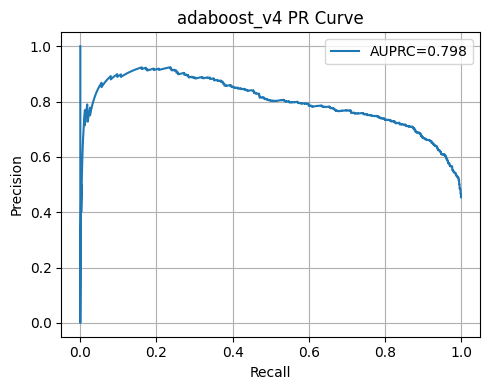

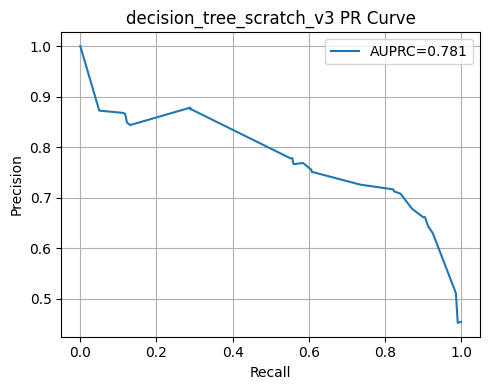

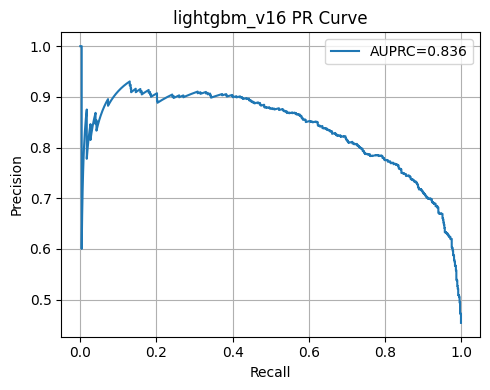

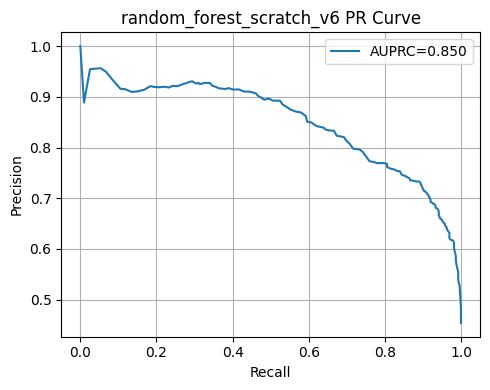

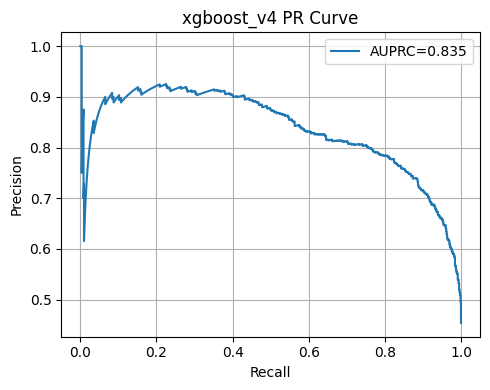

In [21]:
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, auc

from CartClassifier import CARTClassifier
from RandomForestFromScratch import RandomForestFromScratch

for _, row in best_by_family.iterrows():

    name = row["model_name"]
    path = row["model_path"]

    if not os.path.isabs(path):
        path = os.path.join("../models", os.path.basename(path))

    try:
        model = joblib.load(path)

        if not hasattr(model, "predict_proba"):
            print(f"Skipping {name}: no predict_proba")
            continue

        y_prob = model.predict_proba(X_test)[:, 1]

        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall, precision)

        # individual plot
        plt.figure(figsize=(5,4))

        plt.plot(recall, precision, label=f"AUPRC={pr_auc:.3f}")

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{name} PR Curve")

        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error loading {name}: {e}")

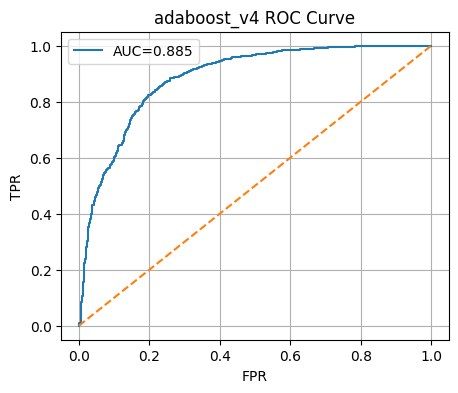

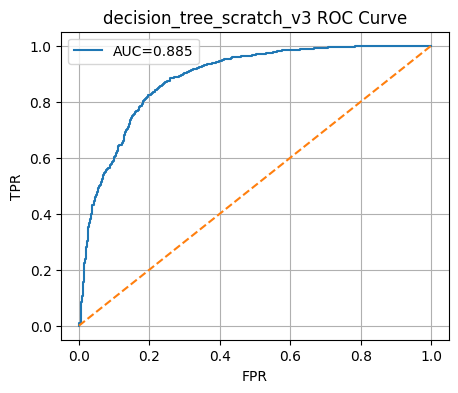

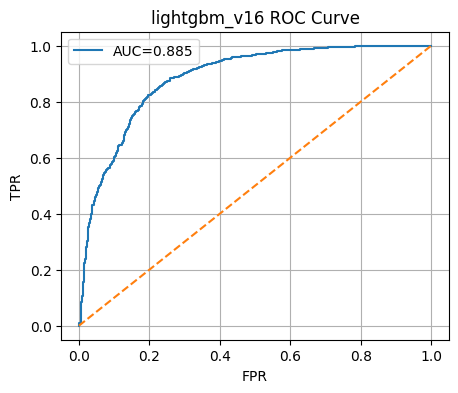

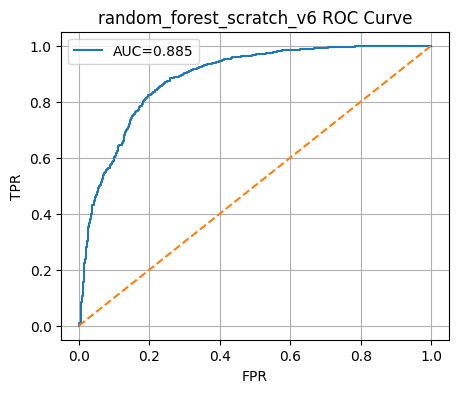

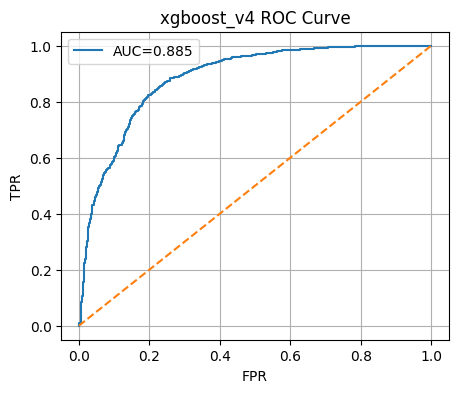

In [22]:
from sklearn.metrics import roc_curve, auc

for _, row in best_by_family.iterrows():

    name = row["model_name"]
    path = row["model_path"]

    if not os.path.isabs(path):
        path = os.path.join("../models", os.path.basename(path))

    model = joblib.load(path)

    #y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{name} ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

In [23]:
import numpy as np
thresholds = np.linspace(0, 1, 50)

for _, row in best_by_family.iterrows():

    name = row["model_name"]
    path = row["model_path"]

    if not os.path.isabs(path):
        path = os.path.join("../models", os.path.basename(path))

    model = joblib.load(path)

    # skip models without probabilities (e.g. old DT)
    if not hasattr(model, "predict_proba"):
        print(f"Skipping {name}")
        continue

    y_prob = model.predict_proba(X_test)[:, 1]

    precisions = []
    recalls = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_test, y_pred))
        recalls.append(recall_score(y_test, y_pred))

    plt.figure(figsize=(5,4))
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, recalls, label="Recall")

    plt.title(name)
    plt.xlabel("Threshold")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

NameError: name 'precision_score' is not defined